#**TATA TRENT (ZUDIO & WESTSIDE)** -(Customer Shopping Behavior Analysis in Retail)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/Share zudio_westside_customer_shopping_dataset.csv")

**SUMMARY** **STATISTICS**

In [3]:
# df.describe()
df.shape


(5000, 20)

In [4]:
df.head()

,Transaction_ID,Customer_ID,Brand,Age_Group,Gender,City_Tier,City,Sales_Channel,Season,Product_Category,Unit_Price_INR,Quantity,Subtotal_INR,Discount_Pct,Final_Amount_INR,Rating,Review_Count,Payment_Method,Purchase_Frequency,Repeat_Purchase
0,TXN55994083,CUST670872,Zudio,25-34,Female,Tier 2,Indore,Online,Festive,Trousers,1230,1,1230,30,861,4.0,10,UPI,One-time,0
1,TXN57616149,CUST614993,Westside,25-34,Female,Tier 1,Pune,Offline,Festive,Accessories,680,2,1360,20,1088,3.6,9,UPI,Regular,1
2,TXN32542880,CUST152757,Zudio,25-34,Female,Tier 2,Vadodara,Offline,Festive,Jeans,1520,1,1520,10,1368,3.6,8,Cash,Occasional,0
3,TXN05736648,CUST518394,Zudio,18-24,Male,Tier 2,Patna,Offline,Festive,Trousers,1210,1,1210,15,1028,3.7,11,Cash,Regular,1
4,TXN52369596,CUST897271,Westside,25-34,Male,Tier 1,Hyderabad,Offline,Winter,Jeans,1960,2,3920,20,3136,4.6,7,UPI,Regular,1


**missing values check**

In [5]:
df.isna().sum()

,0
Transaction_ID,0
Customer_ID,0
Brand,0
Age_Group,0
Gender,0
City_Tier,0
City,0
Sales_Channel,0
Season,0
Product_Category,0


**check for duplicate values if any**

In [6]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("After Removing Duplicates:", df.shape)


Duplicates: 0
After Removing Duplicates: (5000, 20)


#**FEATURE ENGINEERING**

In [7]:
#1. Discount amount
df["Discount_Amount"] = df["Subtotal_INR"] - df["Final_Amount_INR"]
# display(df["Discount_Amount"].head(10))



In [8]:
#2. customer total spend
df["Customer_Total_Spend"] = (
    df.groupby("Customer_ID")["Final_Amount_INR"]
      .transform("sum")
)
# display(df["Customer_Total_Spend"].head(10))


In [9]:
#3. customer total order

df["Customer_Total_Orders"] = (
    df.groupby("Customer_ID")["Transaction_ID"]
      .transform("count")
)
# display(df["Customer_Total_Orders"].head(10))



In [10]:
# 4. Average discount per customer
df["Avg_Discount_Per_Customer"] = (
    df.groupby("Customer_ID")["Discount_Pct"]
      .transform("mean")
)


In [11]:

#5 High value customer

df["High_Value_Customer"] = (
    df["Customer_Total_Spend"] > df["Customer_Total_Spend"].median()
).astype(int)
print(df["High_Value_Customer"].value_counts())

High_Value_Customer
0    2503
1    2497
Name: count, dtype: int64


identify premium customers
✔ Target high-value customers for loyalty programs
✔ Improve repeat purchase prediction
✔ Focus marketing budget efficiently

In [12]:
median_customer_spend = df['Customer_Total_Spend'].median()
print(f"Median Customer Total Spend: {median_customer_spend}")

Median Customer Total Spend: 1156.0


In [13]:
display(df.head(50))

,Transaction_ID,Customer_ID,Brand,Age_Group,Gender,City_Tier,City,Sales_Channel,Season,Product_Category,...,Rating,Review_Count,Payment_Method,Purchase_Frequency,Repeat_Purchase,Discount_Amount,Customer_Total_Spend,Customer_Total_Orders,Avg_Discount_Per_Customer,High_Value_Customer
0,TXN55994083,CUST670872,Zudio,25-34,Female,Tier 2,Indore,Online,Festive,Trousers,...,4.0,10,UPI,One-time,0,369,861,1,30.0,0
1,TXN57616149,CUST614993,Westside,25-34,Female,Tier 1,Pune,Offline,Festive,Accessories,...,3.6,9,UPI,Regular,1,272,1088,1,20.0,0
2,TXN32542880,CUST152757,Zudio,25-34,Female,Tier 2,Vadodara,Offline,Festive,Jeans,...,3.6,8,Cash,Occasional,0,152,1368,1,10.0,1
3,TXN05736648,CUST518394,Zudio,18-24,Male,Tier 2,Patna,Offline,Festive,Trousers,...,3.7,11,Cash,Regular,1,182,1028,1,15.0,0
4,TXN52369596,CUST897271,Westside,25-34,Male,Tier 1,Hyderabad,Offline,Winter,Jeans,...,4.6,7,UPI,Regular,1,784,3136,1,20.0,1
5,TXN11498784,CUST365885,Zudio,18-24,Female,Tier 2,Bhopal,Online,Summer,Trousers,...,3.8,17,Card,One-time,0,708,1652,1,30.0,1
6,TXN15448181,CUST985533,Westside,18-24,Male,Tier 2,Indore,Offline,Winter,T-Shirts,...,3.9,5,Card,Occasional,0,88,792,1,10.0,0
7,TXN33149848,CUST045968,Westside,25-34,Female,Tier 3,Mysuru,Offline,Monsoon,Shirts,...,3.8,6,Cash,Frequent,1,60,1140,1,5.0,0
8,TXN60952394,CUST936878,Zudio,18-24,Male,Tier 1,Mumbai,Offline,Festive,Accessories,...,3.5,11,Card,Occasional,0,61,549,1,10.0,0
9,TXN39243244,CUST461899,Westside,25-34,Male,Tier 1,Chennai,Offline,Summer,Accessories,...,3.3,8,Card,Frequent,1,128,382,1,25.0,0


**1. Sales Overview**

In [14]:
total_revenue = df["Final_Amount_INR"].sum()
total_orders = df["Transaction_ID"].nunique()
avg_order_value = df["Final_Amount_INR"].mean()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value, 2))



Total Revenue: 6778596
Total Orders: 5000
Average Order Value: 1355.72


# **Brand wise revenue**

Brand
Zudio       3782024
Westside    2996572
Name: Final_Amount_INR, dtype: int64


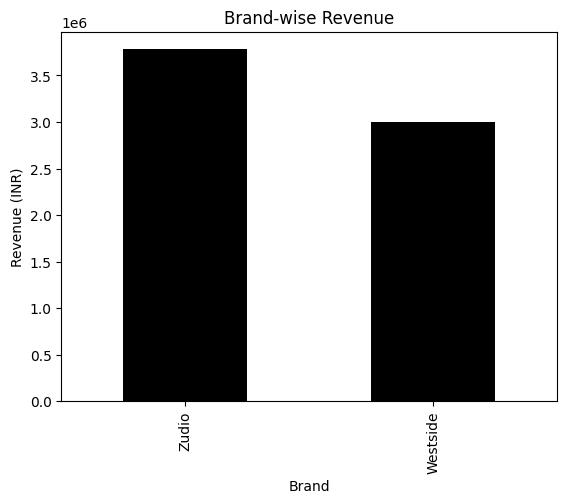

In [15]:
brand_revenue = df.groupby("Brand")["Final_Amount_INR"].sum().sort_values(ascending=False)
print(brand_revenue)

brand_revenue.plot(kind="bar", title="Brand-wise Revenue", color='black')
plt.ylabel("Revenue (INR)")
plt.show()

#**3. Product Category wise sales revenue**

Product_Category
Jeans          1226408
Ethnic Wear    1009586
Dresses         910090
Shirts          843602
Trousers        822630
Footwear        750809
T-Shirts        701671
Accessories     257947
Kids Wear       255853
Name: Final_Amount_INR, dtype: int64


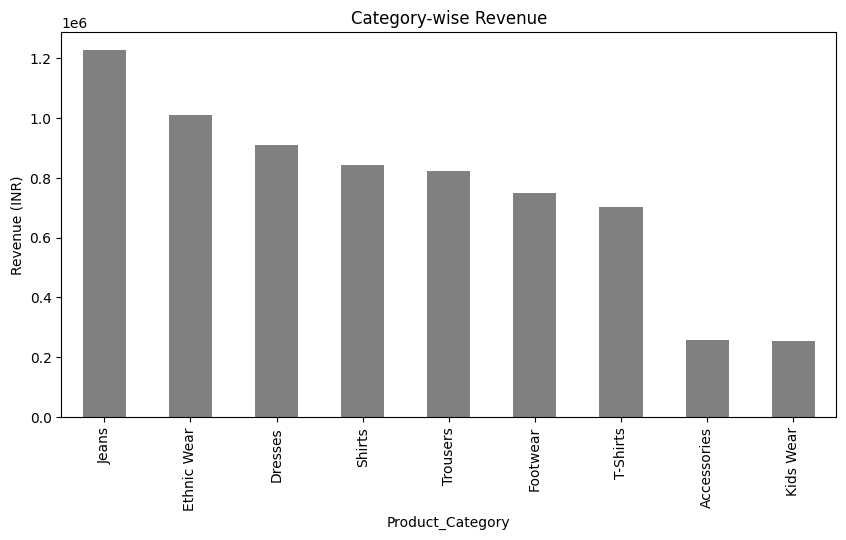

In [16]:
cat_sales = df.groupby("Product_Category")["Final_Amount_INR"].sum().sort_values(ascending=False)
print(cat_sales)

cat_sales.plot(kind="bar", figsize=(10,5), title="Category-wise Revenue", color="grey")
plt.ylabel("Revenue (INR)")
plt.show()


**4. Offline v/s Online** **Behaviour**

Sales_Channel
Offline    3423
Online     1577
Name: count, dtype: int64


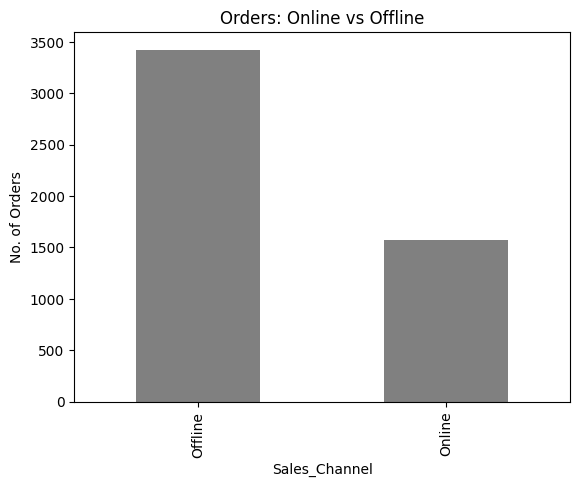

In [17]:
channel_orders = df["Sales_Channel"].value_counts()
print(channel_orders)

channel_orders.plot(kind="bar", title="Orders: Online vs Offline", color="grey")
plt.ylabel("No. of Orders")
plt.show()


**5. Average spending Online v/s offline**

Sales_Channel
Offline    1341.356705
Online     1386.894103
Name: Final_Amount_INR, dtype: float64


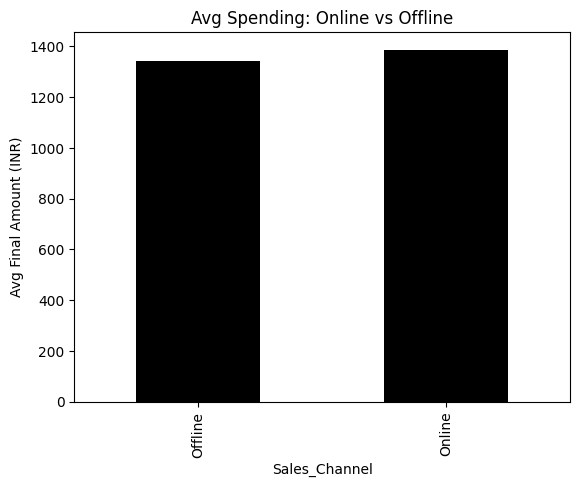

In [18]:
channel_avg = df.groupby("Sales_Channel")["Final_Amount_INR"].mean()
print(channel_avg)

channel_avg.plot(kind="bar", title="Avg Spending: Online vs Offline",color="black")
plt.ylabel("Avg Final Amount (INR)")
plt.show()


#**Discount Behaviour Analysis**
**1.** **Discount % distribution**

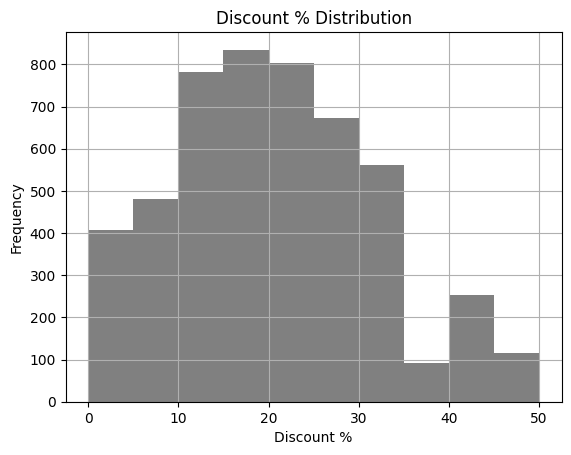

In [19]:
df["Discount_Pct"].hist(bins=10,color="grey")
plt.title("Discount % Distribution")
plt.xlabel("Discount %")
plt.ylabel("Frequency")
plt.show()


**2. Discount impact on revenue**

Discount_Pct
0     1654.864865
5     1597.607069
10    1465.329065
15    1377.771257
20    1323.735990
25    1247.438336
30    1200.418895
35    1279.274725
40     986.347826
45     963.909091
50     781.000000
Name: Final_Amount_INR, dtype: float64


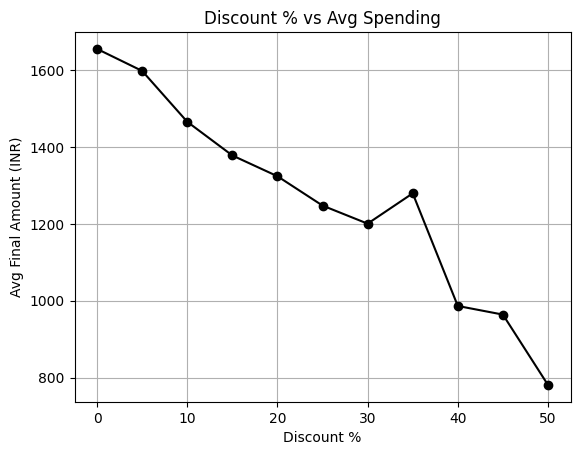

In [20]:
discount_grp = df.groupby("Discount_Pct")["Final_Amount_INR"].mean().sort_index()
print(discount_grp)

discount_grp.plot(kind="line", marker="o", title="Discount % vs Avg Spending",color="black")
plt.xlabel("Discount %")
plt.ylabel("Avg Final Amount (INR)")
plt.grid(True)
plt.show()


#**Ratings Analysis (Customer Satisfaction)**

Brand
Westside    4.139396
Zudio       4.151954
Name: Rating, dtype: float64


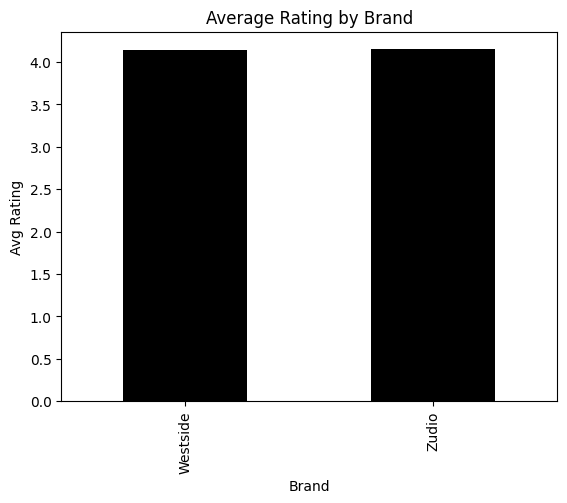

In [21]:
rating_avg = df.groupby("Brand")["Rating"].mean()
print(rating_avg)

rating_avg.plot(kind="bar", title="Average Rating by Brand",color="black")
plt.ylabel("Avg Rating")
plt.show()


#**Payment Preference Analysis**

Payment_Method
UPI           2175
Card          1217
Cash           960
Wallet         543
NetBanking     105
Name: count, dtype: int64


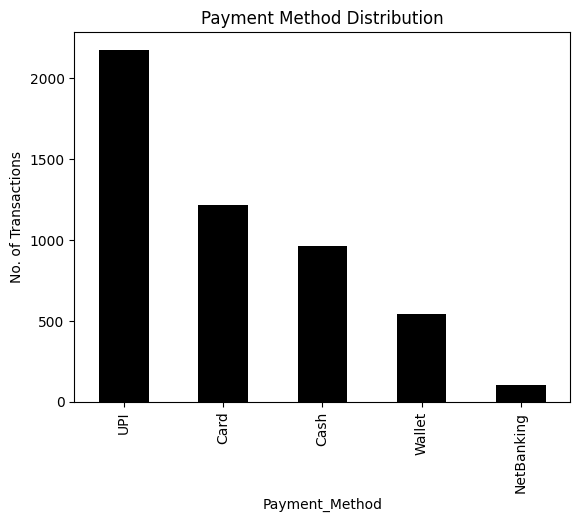

In [22]:
payment_counts = df["Payment_Method"].value_counts()
print(payment_counts)

payment_counts.plot(kind="bar", title="Payment Method Distribution",color="black")
plt.ylabel("No. of Transactions")
plt.show()


#**Demographic Behaviour Analysis**

**1. Age group vs spending**

Age_Group
55+      1459.140000
18-24    1408.845683
35-44    1327.619048
25-34    1326.494587
45-54    1295.204724
Name: Final_Amount_INR, dtype: float64


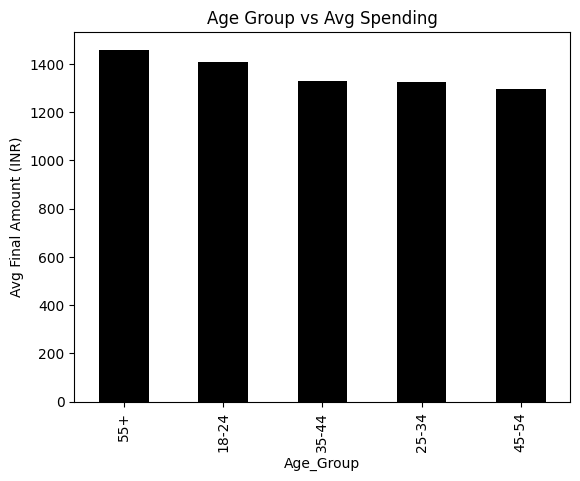

In [23]:
age_spend = df.groupby("Age_Group")["Final_Amount_INR"].mean().sort_values(ascending=False)
print(age_spend)

age_spend.plot(kind="bar", title="Age Group vs Avg Spending",color="black")
plt.ylabel("Avg Final Amount (INR)")
plt.show()


**2. Gender vs spending**

Gender
Male      1366.700244
Female    1348.749079
Other     1250.378947
Name: Final_Amount_INR, dtype: float64


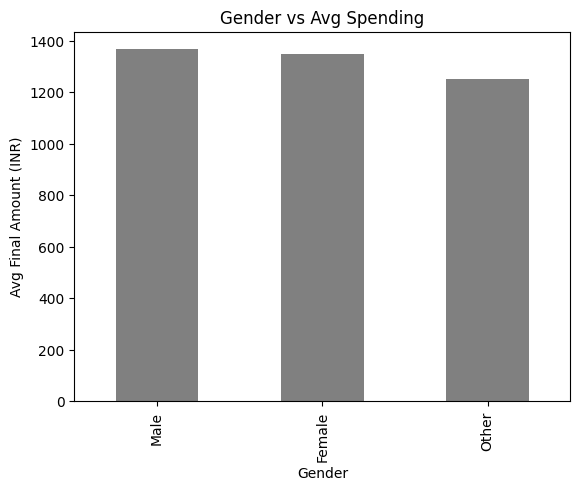

In [24]:
gender_spend = df.groupby("Gender")["Final_Amount_INR"].mean().sort_values(ascending=False)
print(gender_spend)

gender_spend.plot(kind="bar", title="Gender vs Avg Spending",color="grey")
plt.ylabel("Avg Final Amount (INR)")
plt.show()


# **Per Season Analysis**

Season
Festive    2207824
Summer     1869050
Winter     1431193
Monsoon    1270529
Name: Final_Amount_INR, dtype: int64


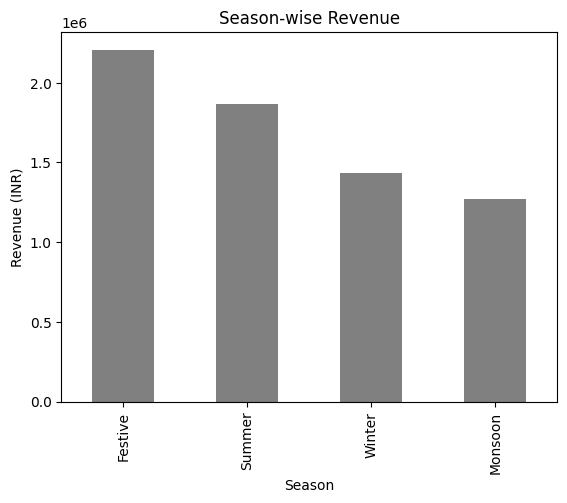

In [25]:
season_revenue = df.groupby("Season")["Final_Amount_INR"].sum().sort_values(ascending=False)
print(season_revenue)

season_revenue.plot(kind="bar", title="Season-wise Revenue",color="Grey")
plt.ylabel("Revenue (INR)")
plt.show()


# **Repeat Purchase Behaviour**
**1. Repeat vs Non-repeat customers**

Repeat_Purchase
0    2590
1    2410
Name: count, dtype: int64


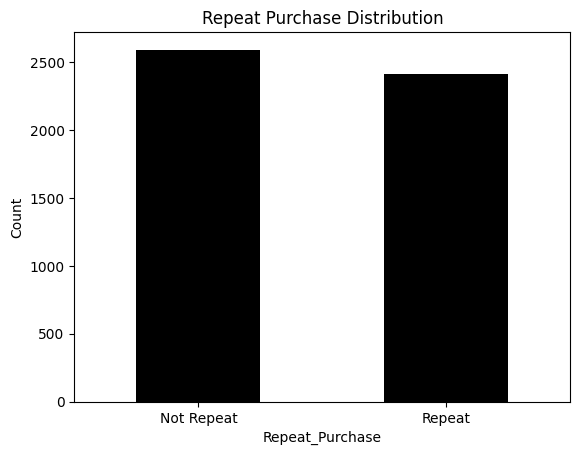

In [26]:
repeat_counts = df["Repeat_Purchase"].value_counts()
print(repeat_counts)

repeat_counts.plot(kind="bar", title="Repeat Purchase Distribution",color="black")
plt.xticks([0,1], ["Not Repeat", "Repeat"], rotation=0)
plt.ylabel("Count")
plt.show()


**2. Repeat rate by Brand**

Brand
Westside    48.623853
Zudio       47.950429
Name: Repeat_Purchase, dtype: float64


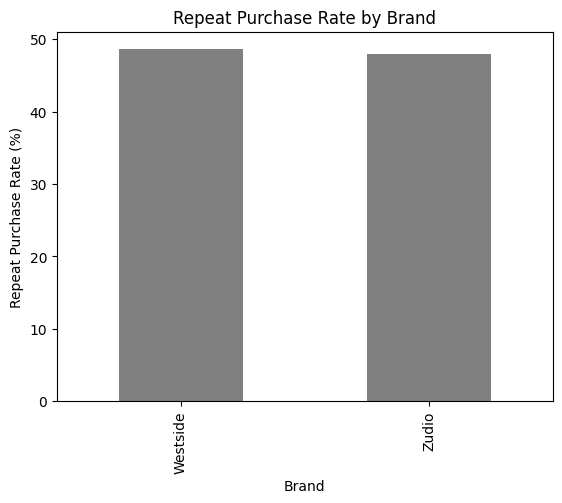

In [27]:
repeat_rate_brand = df.groupby("Brand")["Repeat_Purchase"].mean() * 100
print(repeat_rate_brand)

repeat_rate_brand.plot(kind="bar", title="Repeat Purchase Rate by Brand",color="grey")
plt.ylabel("Repeat Purchase Rate (%)")
plt.show()


**3. Repeat rate by Channel**

Sales_Channel
Offline    50.131464
Online     44.007609
Name: Repeat_Purchase, dtype: float64


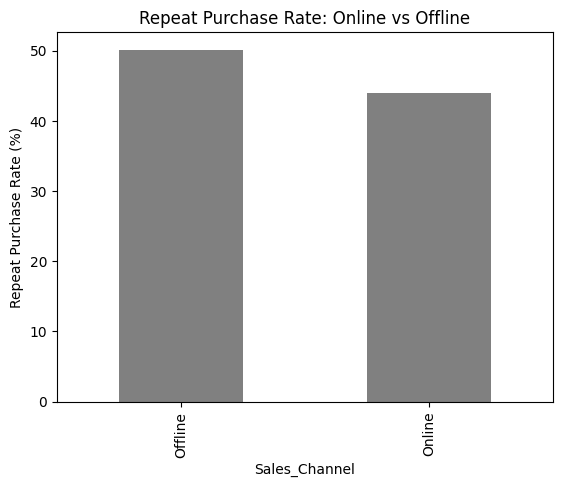

In [28]:
repeat_rate_channel = df.groupby("Sales_Channel")["Repeat_Purchase"].mean() * 100
print(repeat_rate_channel)

repeat_rate_channel.plot(kind="bar", title="Repeat Purchase Rate: Online vs Offline",color="grey")
plt.ylabel("Repeat Purchase Rate (%)")
plt.show()


In [29]:
display("Top Category Revenue:", cat_sales.head(3))
display("Top Payment Method:", payment_counts.head(1))
display("Best Season Revenue:", season_revenue.head(1))
display("Repeat Rate by Brand:", repeat_rate_brand)


'Top Category Revenue:'

,Final_Amount_INR
Product_Category,
Jeans,1226408
Ethnic Wear,1009586
Dresses,910090


'Top Payment Method:'

,count
Payment_Method,
UPI,2175


'Best Season Revenue:'

,Final_Amount_INR
Season,
Festive,2207824


'Repeat Rate by Brand:'

,Repeat_Purchase
Brand,
Westside,48.623853
Zudio,47.950429


# **Logistic Regression (Repeat Purchase Prediction)**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


X = df.drop(["Repeat_Purchase", "Transaction_ID", "Customer_ID"], axis=1)
y = df["Repeat_Purchase"]
cat_cols = X.select_dtypes(include="object").columns  #brand, season, channel
num_cols = X.select_dtypes(exclude="object").columns  #quantity, ratings, amount, discount%


preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

# Model Pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

